In [7]:
my_list = [3,2,5]

In [8]:
sorted(my_list)

[2, 3, 5]

In [9]:
my_list = [3,2,5]

In [10]:
sorted(my_list)

[2, 3, 5]

In [11]:
import tensorflow as tf


In [12]:
x = tf.ones(shape=(2, 1))
print(x)


tf.Tensor(
[[1.]
 [1.]], shape=(2, 1), dtype=float32)


In [13]:
x= tf.zeros(shape=(2,1))

In [14]:
print(x)

tf.Tensor(
[[0.]
 [0.]], shape=(2, 1), dtype=float32)


In [15]:
#Random tensors
x = tf.random.normal(shape = (3,1), mean = 0., stddev=1.)

In [16]:
print(x)

tf.Tensor(
[[1.0214293 ]
 [0.82139194]
 [0.59507364]], shape=(3, 1), dtype=float32)


In [17]:
x = tf.random.uniform(shape=(3,1), minval=0., maxval=1.)

In [18]:
print(x)

tf.Tensor(
[[0.3963486]
 [0.8245853]
 [0.6606947]], shape=(3, 1), dtype=float32)


In [23]:
#Numpy arrays are assignable
import numpy as np
x=np.ones(shape=(2,2))
x[0, 0]=0.

In [24]:
#In tensorflow, it gives an error as a tensor is not assignable
x=  tf.ones(shape =(2, 2))
x[0, 0] = 0.0

TypeError: 'tensorflow.python.framework.ops.EagerTensor' object does not support item assignment

In [25]:
#Creating tensorflow variable
v = tf.Variable(initial_value=tf.random.normal(shape=(3, 1)))

In [27]:
print(v)

<tf.Variable 'Variable:0' shape=(3, 1) dtype=float32, numpy=
array([[ 0.61378473],
       [ 0.57567155],
       [-1.281844  ]], dtype=float32)>


In [29]:
#The state of a variable can be modified via its assign method
v.assign(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[1.],
       [1.],
       [1.]], dtype=float32)>

In [30]:
#Assigning a value to a subset of a TensorFlow variable
v[0, 0].assign(3.)

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[3.],
       [1.],
       [1.]], dtype=float32)>

In [31]:
#assign_add() and assign_sub() are efficient equivalents of += and -=
v.assign_add(tf.ones((3, 1)))

<tf.Variable 'UnreadVariable' shape=(3, 1) dtype=float32, numpy=
array([[4.],
       [2.],
       [2.]], dtype=float32)>

In [38]:
#A few basic math operations
a = tf.ones((2, 2))
b = tf.square(a)
c = tf.sqrt(a)
d = b + c
e = tf.matmul(a, b)


In [33]:
a

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[1., 1.],
       [1., 1.]], dtype=float32)>

In [34]:
b

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[1., 1.],
       [1., 1.]], dtype=float32)>

In [35]:
c

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[1., 1.],
       [1., 1.]], dtype=float32)>

In [36]:
d

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[2., 2.],
       [2., 2.]], dtype=float32)>

In [39]:
e

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[2., 2.],
       [2., 2.]], dtype=float32)>

In [40]:
e *= d

In [41]:
e

<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[4., 4.],
       [4., 4.]], dtype=float32)>

In [21]:
#GradientTape API
input_var = tf.Variable(initial_value=3.)
with tf.GradientTape() as tape:
    result = tf.square(input_var)
gradient = tape.gradient(result, input_var)
#This is most commonly used to retrieve the gradients of the loss of a model with
#respect to its weights: gradients = tape.gradient(loss, weights).

In [22]:
#Using GradientTape with constant tensor inputs
input_const = tf.constant(3.)
with tf.GradientTape() as tape:
    tape.watch(input_const)
    result = tf.square(input_const)
gradient = tape.gradient(result, input_const)


In [23]:
print(gradient)

tf.Tensor(6.0, shape=(), dtype=float32)


In [ ]:
#Trainable variables are watched by default because computing the gradient of
# a loss with regard to a list of trainable variables is the most common use
# of the gradient tape.
#The gradient tape is a powerful utility, even capable of computing 
#second-order gradients, that is to say, the gradient of a gradient.

In [24]:
#Using nested gradient tapes to compute second-order gradients
time = tf.Variable(0.)
with tf.GradientTape() as outer_tape:
  with tf.GradientTape() as inner_tape:
    position = 4.9 * time ** 2
  speed = inner_tape.gradient(position, time)
acceleration = outer_tape.gradient(speed, time)
#Use the outer tape to compute the gradient of the gradient from the inner tape

In [25]:
#Generating two classes of random points in a 2D plane
num_samples_per_class = 1000
negative_samples = np.random.multivariate_normal(
    mean=[0, 3],
    cov=[[1, 0.5],[0.5, 1]],
    size=num_samples_per_class)
positive_samples = np.random.multivariate_normal(
    mean=[3, 0],
    cov=[[1, 0.5],[0.5, 1]],
    size=num_samples_per_class)

In [26]:
#negative_samples and positive_samples are both arrays
#with shape (1000, 2). Let’s stack them into a single array with shape (2000, 2).

In [27]:
inputs = np.vstack((negative_samples, positive_samples)).astype(np.float32)

In [28]:
#Generating the corresponding targets (0 and 1)
targets = np.vstack((np.zeros((num_samples_per_class, 1), dtype="float32"),
np.ones((num_samples_per_class, 1), dtype="float32")))

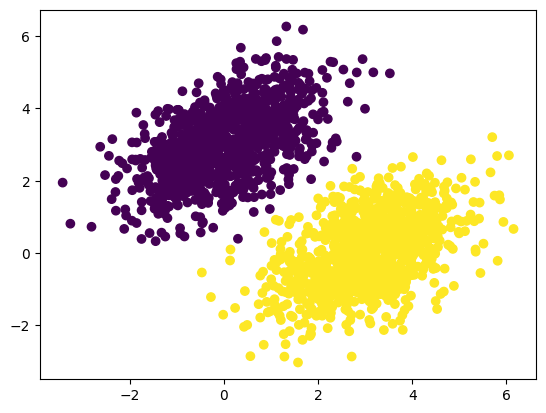

In [29]:
#Using matplotlib, Plotting the two point classes
import matplotlib.pyplot as plt
plt.scatter(inputs[:, 0], inputs[:, 1], c=targets[:, 0])
plt.show()

In [30]:
#create a linear classifier that can learn to separate these two blobs. 
#A linear classifier is an affine transformation (prediction = W • input + b) 
#trained to minimize the square of the difference between predictions and
# the targets.

In [31]:
#Creating the linear classifier variables
input_dim = 2
output_dim = 1
W = tf.Variable(initial_value=tf.random.uniform(shape=(input_dim, output_dim)))
b = tf.Variable(initial_value=tf.zeros(shape=(output_dim,)))

In [32]:
#The forward pass function
def model(inputs):
    return tf.matmul(inputs, W) + b

In [33]:
#The mean squared error loss function
def square_loss(targets, predictions):
    per_sample_losses = tf.square(targets - predictions)
    return tf.reduce_mean(per_sample_losses)

In [34]:
#To train data, The training step function
learning_rate = 0.1
def training_step(inputs, targets):
    with tf.GradientTape() as tape:
        predictions = model(inputs)
        loss = square_loss(predictions, targets)
    grad_loss_wrt_W, grad_loss_wrt_b = tape.gradient(loss, [W, b])
    W.assign_sub(grad_loss_wrt_W * learning_rate)
    b.assign_sub(grad_loss_wrt_b * learning_rate)
    return loss

In [35]:
#The batch training loop
for step in range(40):
    loss = training_step(inputs, targets)
    print(f"Loss at step {step}: {loss:.4f}")
#Loss stabilized at 0.0293

Loss at step 0: 3.6921
Loss at step 1: 0.6100
Loss at step 2: 0.2090
Loss at step 3: 0.1344
Loss at step 4: 0.1153
Loss at step 5: 0.1061
Loss at step 6: 0.0990
Loss at step 7: 0.0928
Loss at step 8: 0.0872
Loss at step 9: 0.0820
Loss at step 10: 0.0772
Loss at step 11: 0.0729
Loss at step 12: 0.0689
Loss at step 13: 0.0652
Loss at step 14: 0.0619
Loss at step 15: 0.0588
Loss at step 16: 0.0560
Loss at step 17: 0.0534
Loss at step 18: 0.0511
Loss at step 19: 0.0489
Loss at step 20: 0.0469
Loss at step 21: 0.0451
Loss at step 22: 0.0434
Loss at step 23: 0.0419
Loss at step 24: 0.0405
Loss at step 25: 0.0392
Loss at step 26: 0.0381
Loss at step 27: 0.0370
Loss at step 28: 0.0360
Loss at step 29: 0.0351
Loss at step 30: 0.0343
Loss at step 31: 0.0335
Loss at step 32: 0.0328
Loss at step 33: 0.0322
Loss at step 34: 0.0316
Loss at step 35: 0.0310
Loss at step 36: 0.0306
Loss at step 37: 0.0301
Loss at step 38: 0.0297
Loss at step 39: 0.0293


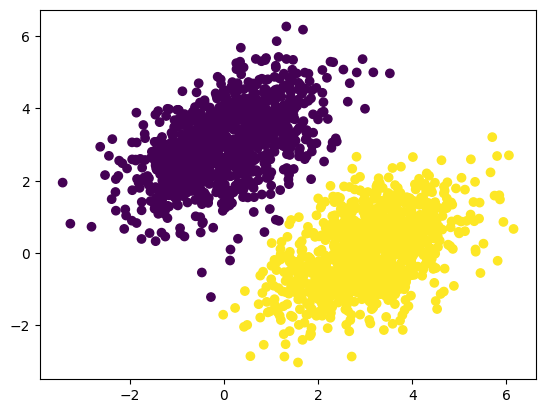

In [36]:
#Plot how our linear model classifies the training data points.
#targets are zeros and ones, a given input point will be classified as “0” 
#if its prediction value is below 0.5, and as “1” if it is above 0.5
predictions = model(inputs)
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)
plt.show()

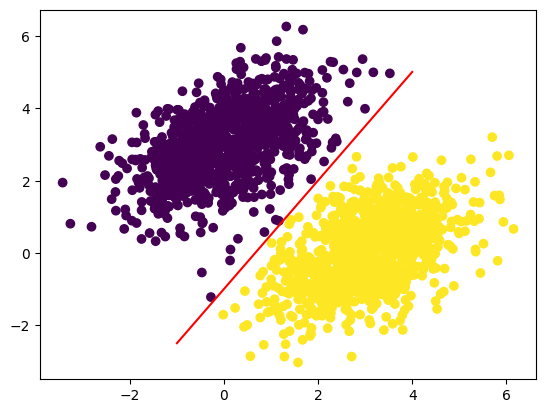

In [37]:
x = np.linspace(-1, 4, 100)
#Line equation
y = - W[0] / W[1] * x + (0.5 - b) / W[1]
plt.plot(x, y, "-r")
plt.scatter(inputs[:, 0], inputs[:, 1], c=predictions[:, 0] > 0.5)

In [38]:
"""A layer is a data processing module that takes as input one or
more tensors and that outputs one or more tensors. Some layers are stateless, but
more frequently layers have a state: the layer’s weights, one or several tensors learned
with stochastic gradient descent, which together contain the network’s knowledge"""

'A layer is a data processing module that takes as input one or\nmore tensors and that outputs one or more tensors. Some layers are stateless, but\nmore frequently layers have a state: the layer’s weights, one or several tensors learned\nwith stochastic gradient descent, which together contain the network’s knowledge'

In [40]:
#Simple vector data, stored in rank-2 tensors of shape (samples, features), 
#is often processed by densely connected layers, also called fully connected 
#or dense layers (the Dense class in Keras). 
#Sequence data, stored in rank-3 tensors of shape 
#(samples, timesteps, features), is typically processed by recurrent
#layers, such as an LSTM layer, or 1D convolution layers (Conv1D). 
#Image data, stored in rank-4 tensors, is usually processed by 2D convolution 
#layers (Conv2D).

In [41]:
"""A Layer is an object that encapsulates some state (weights) and some computation
(a forward pass). The weights are typically defined in a build() (although they could
also be created in the constructor, __init__()), and the computation is defined in
the call() method."""

'A Layer is an object that encapsulates some state (weights) and some computation\n(a forward pass). The weights are typically defined in a build() (although they could\nalso be created in the constructor, __init__()), and the computation is defined in\nthe call() method.'

In [42]:
#A Dense layer implemented as a Layer subclass
from tensorflow import keras
class SimpleDense(keras.layers.Layer):
  def __init__(self, units, activation=None):
      super().__init__()
      self.units = units
      self.activation = activation
#Creating weight
def build(self, input_shape):
      input_dim = input_shape[-1]
      self.W = self.add_weight(shape=(input_dim, self.units),initializer="random_normal")
      self.b = self.add_weight(shape=(self.units,),initializer="zeros")
#Forward pass computation in the call() method
def call(self, inputs):
      y = tf.matmul(inputs, self.W) + self.b
      if self.activation is not None:
          y = self.activation(y)
      return y

In [48]:
#Initiate layer
my_dense = SimpleDense(units=32, activation=tf.nn.relu)

In [49]:
input_tensor = tf.ones(shape=(2, 784))

In [50]:
output_tensor = my_dense(input_tensor)

In [51]:
print(output_tensor.shape)

(2, 784)


In [52]:
#Automatic shape inference
#Dense layer with 32 output points
from tensorflow.keras import layers
layer = layers.Dense(32, activation="relu")

In [55]:
from tensorflow.keras import models
from tensorflow.keras import layers
model = models.Sequential([
    layers.Dense(32, activation="relu"),
    layers.Dense(32)
])

In [57]:
#!pip install NaiveDense

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
ERROR: Could not find a version that satisfies the requirement NaiveDense (from versions: none)
ERROR: No matching distribution found for NaiveDense


In [59]:
"""model = NaiveSequential([
    NaiveDense(input_size=784, output_size=32, activation="relu"),
    NaiveDense(input_size=32, output_size=64, activation="relu"),
    NaiveDense(input_size=64, output_size=32, activation="relu"),
    NaiveDense(input_size=32, output_size=10, activation="softmax")
])"""

'model = NaiveSequential([\n    NaiveDense(input_size=784, output_size=32, activation="relu"),\n    NaiveDense(input_size=32, output_size=64, activation="relu"),\n    NaiveDense(input_size=64, output_size=32, activation="relu"),\n    NaiveDense(input_size=32, output_size=10, activation="softmax")\n])'

In [60]:
def __call__(self, inputs):
    if not self.built:
        self.build(inputs.shape)
        self.built = True
    return self.call(inputs)
#Call method for base layer

In [62]:
#Using automatic shpe reference
model = keras.Sequential([
  SimpleDense(32, activation="relu"),
  SimpleDense(64, activation="relu"),
  SimpleDense(32, activation="relu"),
  SimpleDense(10, activation="softmax")
])

In [63]:
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(optimizer="rmsprop",
loss="mean_squared_error",
metrics=["accuracy"])

In [64]:
model.compile(optimizer=keras.optimizers.RMSprop(),
loss=keras.losses.MeanSquaredError(),
metrics=[keras.metrics.BinaryAccuracy()])

In [66]:
"""model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=1e-4),
loss=my_custom_loss,
metrics=[my_custom_metric_1, my_custom_metric_2])"""

'model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=1e-4),\nloss=my_custom_loss,\nmetrics=[my_custom_metric_1, my_custom_metric_2])'

In [67]:
"""Choosing the right loss function for the right problem is extremely important: your
network will take any shortcut it can to minimize the loss, so if the objective doesn’t
fully correlate with success for the task at hand, your network will end up doing
things you may not have wanted."""

'Choosing the right loss function for the right problem is extremely important: your\nnetwork will take any shortcut it can to minimize the loss, so if the objective doesn’t\nfully correlate with success for the task at hand, your network will end up doing\nthings you may not have wanted.'

In [68]:
#The fit() method implements the training loop itself
history = model.fit(
    inputs,
    targets,
    epochs=5,
    batch_size=128
)

Epoch 1/5
16/16 [==============================] - 2s 5ms/step - loss: 11.0210 - binary_accuracy: 0.4510
Epoch 2/5
16/16 [==============================] - 0s 5ms/step - loss: 10.5427 - binary_accuracy: 0.4485
Epoch 3/5
16/16 [==============================] - 0s 5ms/step - loss: 10.1416 - binary_accuracy: 0.4475
Epoch 4/5
16/16 [==============================] - 0s 3ms/step - loss: 9.7581 - binary_accuracy: 0.4465
Epoch 5/5
16/16 [==============================] - 0s 5ms/step - loss: 9.3863 - binary_accuracy: 0.4430


In [69]:
#Using validation_data argument
model = keras.Sequential([keras.layers.Dense(1)])
model.compile(optimizer=keras.optimizers.RMSprop(learning_rate=0.1),
              loss=keras.losses.MeanSquaredError(),
              metrics=[keras.metrics.BinaryAccuracy()])
"""To avoid having samples from only one class in the validation data,
shuffle the inputs and targets using a random indices permutation."""
indices_permutation = np.random.permutation(len(inputs))
shuffled_inputs = inputs[indices_permutation]
shuffled_targets = targets[indices_permutation]

"""Reserve 30% of the training inputs and targets for validation
(we’ll exclude these samples from training and reserve them to compute the
 validation loss and metrics)."""

num_validation_samples = int(0.3 * len(inputs))
val_inputs = shuffled_inputs[:num_validation_samples]
val_targets = shuffled_targets[:num_validation_samples]
training_inputs = shuffled_inputs[num_validation_samples:]
training_targets = shuffled_targets[num_validation_samples:]

#Training data, used to update the weights of the model
model.fit(
    training_inputs,
    training_targets,
    epochs=5,
    batch_size=16,
    validation_data=(val_inputs, val_targets)#Validation data, used only
                                            #to monitor the validation loss and metrics
)

Epoch 1/5
88/88 [==============================] - 1s 5ms/step - loss: 0.2973 - binary_accuracy: 0.9307 - val_loss: 0.0462 - val_binary_accuracy: 0.9967
Epoch 2/5
88/88 [==============================] - 0s 3ms/step - loss: 0.0733 - binary_accuracy: 0.9586 - val_loss: 0.0245 - val_binary_accuracy: 1.0000
Epoch 3/5
88/88 [==============================] - 0s 5ms/step - loss: 0.0779 - binary_accuracy: 0.9579 - val_loss: 0.0529 - val_binary_accuracy: 0.9750
Epoch 4/5
88/88 [==============================] - 0s 4ms/step - loss: 0.0753 - binary_accuracy: 0.9471 - val_loss: 0.0932 - val_binary_accuracy: 0.9700
Epoch 5/5
88/88 [==============================] - 0s 4ms/step - loss: 0.0710 - binary_accuracy: 0.9579 - val_loss: 0.0608 - val_binary_accuracy: 0.9783


In [70]:
loss_and_metrics = model.evaluate(val_inputs, val_targets, batch_size=128)

5/5 [==============================] - 0s 5ms/step - loss: 0.0608 - binary_accuracy: 0.9783


In [ ]:
"""evaluate() will iterate in batches (of size batch_size) over the data passed and
return a list of scalars, where the first entry is the validation loss and the following
entries are the validation metrics."""

In [71]:
"""Once you’ve trained your model, you’re going to want to use it to make 
predictions on new data. This is called inference"""

'Once you’ve trained your model, you’re going to want to use it to make \npredictions on new data. This is called inference'

In [73]:
#predictions = model(new_inputs)

In [75]:
#A better way to do inference is to use the predict() method
#predictions = model.predict(new_inputs, batch_size=128)

In [76]:
predictions = model.predict(val_inputs, batch_size=128)

5/5 [==============================] - 0s 2ms/step


In [77]:
print(predictions[:10])

[[ 0.807344  ]
 [ 0.8124748 ]
 [ 1.09079   ]
 [-0.19980884]
 [ 0.635951  ]
 [-0.0365777 ]
 [-0.0379644 ]
 [ 0.820504  ]
 [ 0.7361418 ]
 [ 0.5583329 ]]
